In [104]:
import sys
sys.path.append("..")
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from src.preprocessing import load_data, get_preprocessed_split, get_split
from src.metrics import profit_summary, cv_with_threshold, tune_threshold


## Krok 2 — Baseline model


In [105]:
X_train_t, X_test_t, y_train, y_test, salaries_test, preprocessor = get_preprocessed_split(load_data())
X_train_raw, _, _, _, _ = get_split(load_data())
salaries_train = X_train_raw["EstimatedSalary"].values

In [106]:
baseline = LogisticRegression()
baseline.fit(X_train_t, y_train)
y_pred = baseline.predict(X_test_t)

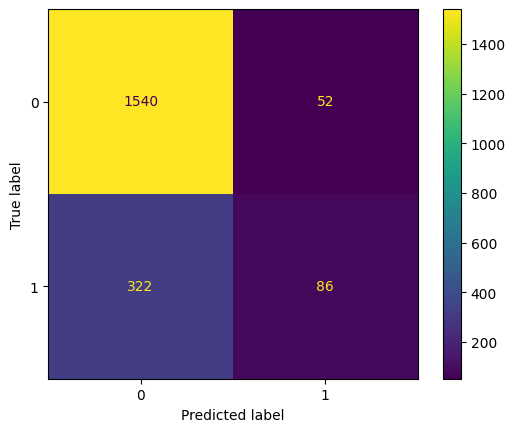

TN = 1540  FP = 52
FN = 322  TP = 86


In [107]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=baseline.classes_)
disp.plot()
plt.show()
print(f"TN = {cm[0, 0]}  FP = {cm[0, 1]}")
print(f"FN = {cm[1, 0]}  TP = {cm[1, 1]}")

In [108]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1592
           1       0.62      0.21      0.32       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000



In [109]:
profit_summary(y_test, y_pred, salaries_test)

Nasz model:                 486551.96 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  281805.57 $
Przewaga nad no_discount:    -3615.47 $


{'model': np.float64(486551.96),
 'all_discount': np.float64(204746.39),
 'no_discount': np.float64(490167.43)}

Z tego co otzrymaliśmy możemy wywnioskować że dla baseline nasz próg 0.5 nie sprawdza się z naszym algorytmie. Zbyt zachowawczo stwierdza że bardzo dużo chunerów zostanie, przez co FN = 322. jest to problem ponieważ wtedy bank zarabia 0%. Przy obecnych prametrach model jest gorszy niż nic nie robienie(Przewaga nad no_discount: -3615.47 $), co trzeba zmienić. 

## Krok 3 — Selekcja cech
Analizujemy współczynniki baseline modelu, a następnie testujemy SelectKBest dla różnych wartości k.


In [110]:
print(np.shape(baseline.coef_))
coefs = baseline.coef_.flatten()
names = preprocessor.get_feature_names_out()

df = pd.DataFrame({
    "Coeff": coefs,
    "Feature": names
})
df.sort_values(by="Coeff", key=abs, ascending=False)

(1, 16)


,Coeff,Feature
15,-1.008112,bin__IsActiveMember
8,0.819756,cat__Geography_Germany
1,0.740193,num__Age
10,-0.527480,cat__Gender_Male
11,-0.175079,cat__Card Type_GOLD
3,0.163499,num__Balance
12,-0.119661,cat__Card Type_PLATINUM
14,-0.093958,bin__HasCrCard
13,-0.079344,cat__Card Type_SILVER
0,-0.079112,num__CreditScore


In [111]:
ks = [4, 6, 8, 10, 12, 14, 16]
results = []
for k in ks:
    pipe = Pipeline([
        ("selector", SelectKBest(f_classif, k=k)),
        ("model", LogisticRegression())
    ])
    mean_profit = cv_with_threshold(pipe, X_train_t, y_train, salaries_train)
    results.append({"k": k, "mean_profit": mean_profit["mean"]})

df = pd.DataFrame(results)
print(df)

    k  mean_profit
0   4   379068.476
1   6   379061.220
2   8   379346.860
3  10   379265.910
4  12   379209.120
5  14   379061.656
6  16   379115.156


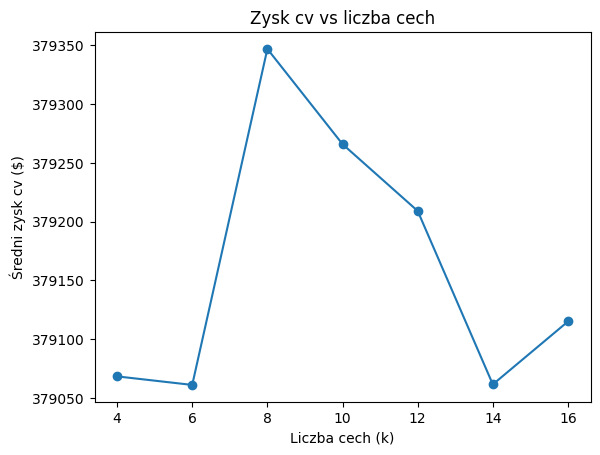

In [112]:
plt.plot(ks, [r["mean_profit"] for r in results], marker="o")
plt.title("Zysk cv vs liczba cech")
plt.xlabel("Liczba cech (k)")
plt.ylabel("Średni zysk cv ($)")
plt.show()

Z wykresu wyraźnie widzimy że wygrywa k = 8, które dało średni zysk cv na poziomie 379350 $. Oznacza to że tak naprawdę 8 cech nam wystarczy, a reszta to szum i cechy skorelowane. Akurat dla regresji logistycznej mniej cech może byc lepsze, ponieważ jest to model liniowy, i im więcej cechy tym więcej możliwego szumu co wpływa na gorsze predykcje. 

## Krok 4 — Tuning parametru C


In [113]:
cs = [0.001, 0.01, 0.1, 1, 10, 100]
results = []
for c in cs:
    pipe = Pipeline([
        ("selector", SelectKBest(f_classif, k=8)),
        ("model", LogisticRegression(C=c))
    ])
    mean_profit = cv_with_threshold(pipe, X_train_t, y_train, salaries_train)
    results.append({"c": c, "mean_profit": mean_profit["mean"]})

df = pd.DataFrame(results)
print(df)

         c  mean_profit
0    0.001   378258.248
1    0.010   378609.358
2    0.100   379275.886
3    1.000   379346.860
4   10.000   379363.748
5  100.000   379363.748


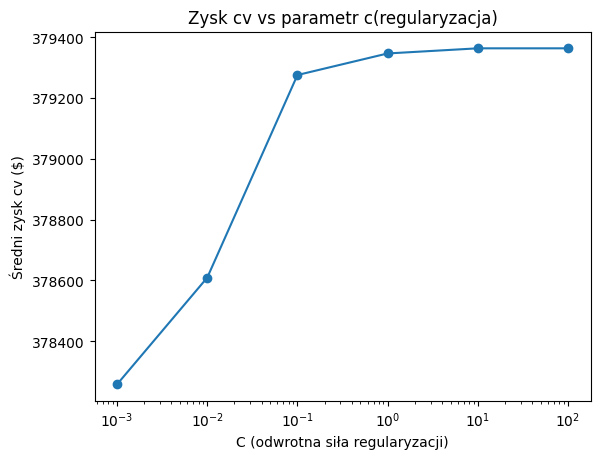

In [114]:
plt.semilogx(cs, [r["mean_profit"] for r in results], marker="o")
plt.title("Zysk cv vs parametr c(regularyzacja)")
plt.xlabel("C (odwrotna siła regularyzacji)")
plt.ylabel("Średni zysk cv ($)")
plt.show()

Ponownie z wykresu możemy zauważyc że dla c = 10 oraz c = 100 mamy najlepsze wyniki. Te same wyniki oznaczają że dalej regularyzacja nie wpływa juz nam na średni zysk. Z tej pary wybierzemy 10 jako wartość graniczną, ponieważ dzięki temu model będzie prostszy. Sam parametr C to odwrotna siła regularyzacji: małe C- silna regularyzacja(underfitting), duże C - słaba regularyzacja(overfitting)

## Krok 5 — Finalny model


In [115]:
pipe = Pipeline([
        ("selector", SelectKBest(f_classif, k=8)),
        ("model", LogisticRegression(C=10))
    ])

cv_result = cv_with_threshold(pipe, X_train_t, y_train, salaries_train)
threshold = np.mean(cv_result["thresholds"])
print(f"Średni próg z CV: {threshold:.3f}")
print(f"Średni zysk CV: {cv_result['mean']:.2f} ± {cv_result['std']:.2f}")

pipe.fit(X_train_t, y_train)
scores = pipe.predict_proba(X_test_t)[:, 1]

Średni próg z CV: 0.672
Średni zysk CV: 379363.75 ± 6039.86


In [116]:
y_pred_final = (scores >= threshold).astype(int)
print(f"Próg z cv (użyty w teście): {threshold:.3f}")

Próg z cv (użyty w teście): 0.672


Nasz model:                 491150.30 $
Zniżka dla wszystkich:      204746.39 $
Brak zniżek:                490167.43 $
Przewaga nad all_discount:  286403.91 $
Przewaga nad no_discount:      982.87 $


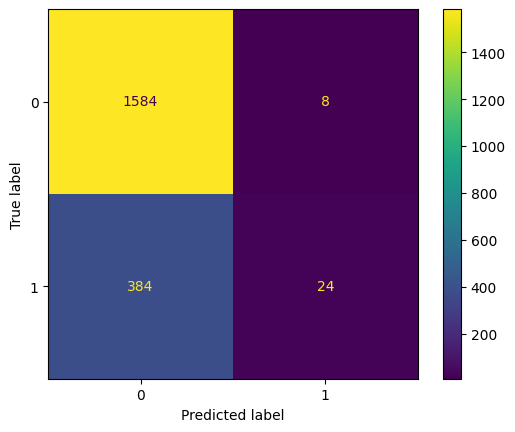

TN = 1584  FP = 8
FN = 384  TP = 24


In [117]:
profit_summary(y_test, y_pred_final, salaries_test)
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=baseline.classes_)
disp.plot()
plt.show()
print(f"TN = {cm[0, 0]}  FP = {cm[0, 1]}")
print(f"FN = {cm[1, 0]}  TP = {cm[1, 1]}")

In [118]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.80      0.99      0.89      1592
           1       0.75      0.06      0.11       408

    accuracy                           0.80      2000
   macro avg       0.78      0.53      0.50      2000
weighted avg       0.79      0.80      0.73      2000



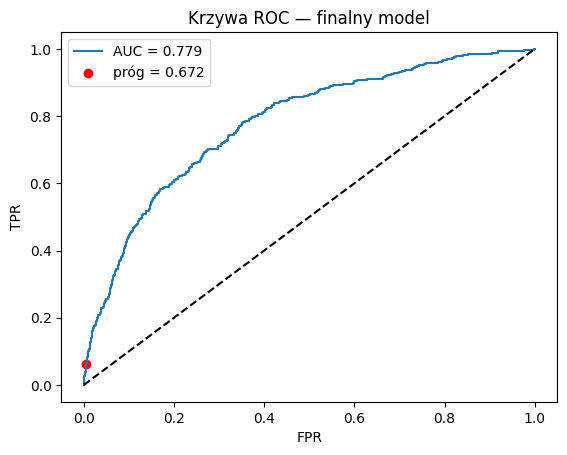

In [119]:
fpr, tpr, thresholds = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")

idx = np.argmin(np.abs(thresholds - threshold))
plt.scatter(fpr[idx], tpr[idx], color="red", label=f"próg = {threshold:.3f}")

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Krzywa ROC — finalny model")
plt.legend()
plt.show()


In [120]:
joblib.dump(pipe, "../models/logistic_reg.pkl")

['../models/logistic_reg.pkl']

## Krok 6 — Podsumowanie


Finalnie, uzyskaliśmy z=lepszy zysk niż w przypadku nic nie robienia o ponad 400$ co jest jednoczesnie lepszym wynikiem niz nasz baseline. recall spadł z 0.21 do 0.07 — mimo to jest to lepszy wynik, ponieważ każdy TN zarabia 0.3% a agresywne łapanie churnerów generuje FP które kosztują 0.2% salary straty. AUC = 0.779, co jest dobrym wynikiem mowi nam, że z losowo wybranej pary (churn, nie-churn), w 77.9% przypadków model da wyższe prawdopodobieństwo churnerowi. Próg wzrósł do 0.672 żebyśmy mieli mniej FP (niepotrzebnych zniżek) i więcej TN (pewnych klientów którzy zostają)

## Wnioski — Baseline

| Model | Zysk | Próg | Recall (klasa 1) | AUC |
|-------|------|------|-----------------|-----|
| Baseline | 486 551$ | 0.5 | 0.21 | - |
| Finalny (k=8, C=10) | 490 575$ | 0.672 | 0.07 | 0.779 |
| Zniżka dla wszystkich | 204 746$ | - | - | - |
| Brak zniżek | 490 167$ | - | - | - |


Model regresji logistycznej bije obie strategie referencyjne, jednak przewaga nad 'brak zniżek' jest niewielka (~400$). Wynika to z charakteru danych — churnerzy stanowią tylko ~20% klientów, a TN generują wysoki zysk (0.3% salary), co sprawia że konserwatywna strategia jest trudna do pobicia. Regresja logistyczna jako model liniowy może nie wychwytywać złożonych zależności w danych — warto porównać z drzewem decyzyjnym i SVM.